# Runtime selection and one high-resolution static map

This first tutorial selects the fastest available public backend, prints the
actual hardware/runtime, and constructs a static IPM magnification map.  The
CUDA path deliberately uses the production-scale $10^7$ ray budget and a
$1024^2$ source plane. The smaller CPU fallback keeps the notebook executable
on laptops.  The displayed field is a point-source magnification map. No
finite-source convolution or display smoothing is applied.

The first invocation may include PyTorch/Triton compilation or an on-disk
compiler-cache lookup.  The repeated values are synchronized steady-state
times.  As in the paper figures, the map uses a physical scale bar rather
than redundant coordinate ticks and shows $\log_{10}\mu$ with a panel-height
colorbar.

The benchmark calls the same map calculation repeatedly and therefore shows first-call versus warmed execution directly. Compatible systems created later in the same Python process reuse the same compiled kernels. For many independent stellar realizations of one macroimage, `mc.batched_system_maps(...)` can fuse compatible maps while keeping every star field scientifically independent. The getting-started and training-set notebooks explain which physical parameters may vary without changing the compiled numerical shapes.


In [1]:
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda and capabilities.triton_importable,
)
print(mcp.runtime_description())


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


In [2]:
stars = mc.PointMassField(
        x_uas=torch.tensor([-1.1, 0.3, 1.4]),
        y_uas=torch.tensor([0.7, -0.4, 0.1]),
        einstein_radius_uas=torch.tensor([0.22, 0.17, 0.20]),
)
lens_region = mc.PlaneRegion((6.0, 6.0))
source_resolution = 1024 if use_cuda else 256
source_grid = mc.PlaneGrid((source_resolution, source_resolution), (4.0, 4.0))
ray_count = 10_000_000 if use_cuda else 262_144
system = mc.MicrolensingSystem(
    macro=mc.MacroLens(convergence=0.35, shear=0.15),
    distances=mc.LensingDistances(8.0e24, 1.6e25, 9.0e24),
    stars=stars, source_grid=source_grid, lens_region=lens_region,
    runtime=runtime_config,
)
method = mc.production_ipm_config(
    dynamic=False,
    rays=ray_count,
    cell_chunk_size=524_288 if use_cuda else 65_536,
)

def make_map():
    return system.magnification_map(method=method)

print(f"Map configuration: N={ray_count:,}, source={source_resolution} x {source_resolution}")


Map configuration: N=10,000,000, source=1024 x 1024


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
static IPM map first call in this process: 3.11904 s
static IPM map warmed steady state: 0.090333 s (median of 3, sample std=0.00276 s)
First-call excess includes compilation when needed, plus allocator and cache initialization. An on-disk compiler cache may already be warm.


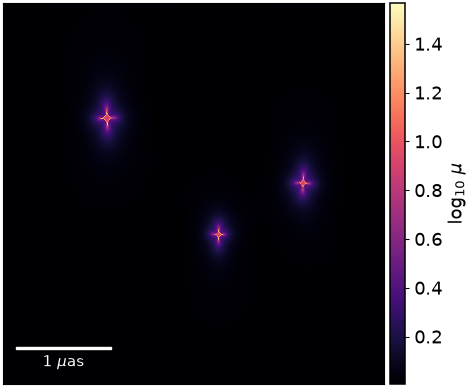

In [3]:
benchmark = mc.benchmark_callable(
    make_map,
    warmup=1,
    repeats=3,
    synchronize=system.realize().simulation.runtime.synchronize,
)
mcp.print_benchmark(benchmark, label="static IPM map")
magnification_map = benchmark.first_result
figure, ax = mcp.plot_magnification_map(
    magnification_map,
    log10=True,
    scale_bar_uas=1.0,
    show_axes=False,
)
figure.tight_layout()


## Eager, compiled, and Triton backends

Backend choice is independent of the numerical IPM controls. The compact
comparison below deliberately uses a smaller map so it can expose first-call
and warmed behavior without repeating the production-scale calculation above.
All available backends receive the same lens, grid, and static-map preset. The
reported maximum difference checks that changing implementation did not change
the requested calculation. `torch-compile-partial` is an honest description of
the portable IPM path. Ray queries are compiled, while exact polygon clipping
remains portable PyTorch. CUDA float32 Triton fuses the complete raster path.


In [4]:
backend_names = ["torch-eager"]
if capabilities.torch_compile_available:
    backend_names.append("torch-compile")
if use_cuda and capabilities.triton_importable:
    backend_names.append("triton")

demo_grid = mc.PlaneGrid((64, 64), (4.0, 4.0))
demo_method = mc.production_ipm_config(
    dynamic=False, rays=16_384, cell_chunk_size=4_096,
)
backend_results = {}
for backend_name in backend_names:
    backend_runtime = mc.RuntimeConfig(
        device="cuda" if use_cuda else "cpu",
        backend=backend_name, dtype=torch.float32, strict_backend=False,
    )
    backend_system = mc.MicrolensingSystem(
        macro=system.macro, distances=system.distances, stars=stars,
        source_grid=demo_grid, lens_region=lens_region, runtime=backend_runtime,
    )
    measured = mc.benchmark_callable(
        lambda: backend_system.magnification_map(method=demo_method),
        warmup=1, repeats=3, synchronize=backend_system.realize().simulation.runtime.synchronize,
    )
    backend_results[backend_name] = measured.first_result
    mcp.print_benchmark(measured, label=backend_name)
    print("  effective backend:", measured.first_result.metadata.get("effective_backend"))

eager_values = backend_results["torch-eager"].values
for backend_name, product in backend_results.items():
    maximum_difference = float((product.values - eager_values).abs().max().cpu())
    print(f"{backend_name:>13s}: max |map - eager| = {maximum_difference:.3e}")


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
torch-eager first call in this process: 4.60882 s
torch-eager warmed steady state: 4.73643 s (median of 3, sample std=0.12 s)
First-call excess includes compilation when needed, plus allocator and cache initialization. An on-disk compiler cache may already be warm.
  effective backend: torch-eager


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
torch-compile first call in this process: 7.40218 s
torch-compile warmed steady state: 4.20127 s (median of 3, sample std=0.121 s)
First-call excess includes compilation when needed, plus allocator and cache initialization. An on-disk compiler cache may already be warm.
  effective backend: torch-compile-partial


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0
triton first call in this process: 1.48152 s
triton warmed steady state: 0.0185011 s (median of 3, sample std=0.00277 s)
First-call excess includes compilation when needed, plus allocator and cache initialization. An on-disk compiler cache may already be warm.
  effective backend: triton
  torch-eager: max |map - eager| = 0.000e+00
torch-compile: max |map - eager| = 1.907e-06
       triton: max |map - eager| = 5.088e-04
